In [5]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm

In [6]:

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [18]:


def plot(mean_dict, ci95_dict, length_dict, title, out_path, ylim=None):

    plt.rcParams.update({'font.size': 24})
    fig, ax = plt.subplots(figsize=(20,10))

    colour_list = ['royalblue', 'tomato', 'skyblue', 'lightsalmon', 'orange']

    for i, key in enumerate(mean_dict.keys()):
        colour = colour_list[i]
        mean = mean_dict[key]
        ci95 = ci95_dict[key]
        length = length_dict[key]
        width = len(mean)
        ax.plot(mean, color=colour, label=f"{key} (n={length:,})")
        ax.fill_between(np.arange(width), mean-ci95, mean+ci95,
                        color=colour, alpha=0.3)

    ax.set_title(title)
    ax.set_xlabel("Position")
    ax.set_ylabel(title)

    ax.set_xticks(np.arange(0, width, 3))
    ax.set_xticklabels(np.arange(0, width, 3))


    ## Vline at center
    ax.axvline(x=width//2, color="black", linestyle="--")

    ax.legend()
    if ylim is not None:
        ax.set_ylim(ylim)
    plt.savefig(f"{out_path}/{title}.pdf")
    plt.savefig(f"{out_path}/{title}.png", dpi=300)
    plt.show()
    plt.close()
    

    return None


In [ ]:

feature_list = ["signal_mean","signal_median","signal_std","signal_len_log10","signal_amp","signal_rms","bq"]

ylim_dict = {}
ON0092_df = pd.read_pickle(f"/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0092/ON0092/result/dorado-070/intermediates/segmented_tokenized/signal_analysis/sampled.pkl")
ON0096_df = pd.read_pickle(f"/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0096/result/dorado-070/intermediates/segmented_tokenized/signal_analysis/sampled.pkl")
ON0099_df = pd.read_pickle(f"/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0099/result/dorado-070/intermediates/segmented_tokenized/signal_analysis/sampled.pkl")

In [9]:
ON0118_df = pd.read_pickle(f"/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0118/ON0118/result/intermediates/segmented_tokenized/signal_analysis/sampled.pkl")
df_dict = {"ON0092": ON0092_df, "ON0096": ON0096_df, "ON0099": ON0099_df, "ON0118": ON0118_df}

In [10]:
out_path = "/extdata4/baeklab/Hyeonseo/m6A/plot/feature_analysis"
os.makedirs(out_path, exist_ok = True)
for feature in ["signal_mean","bq"]:
    feature_renamed = f"{feature}"

    data_dict = {df_name: np.stack(df[feature].values) for df_name, df in df_dict.items()}

    mean_dict = {df_name: np.mean(data, axis=0) for df_name, data in data_dict.items()}
    ci95_dict = {df_name: 1.96*np.std(data, axis=0)/np.sqrt(data.shape[0]) for df_name, data in data_dict.items()}
    length_dict = {df_name: data.shape[0] for df_name, data in data_dict.items()}

    plot(mean_dict, ci95_dict, length_dict, feature_renamed, out_path)


In [11]:
out_path = "/extdata4/baeklab/Hyeonseo/m6A/plot/feature_analysis"
os.makedirs(out_path, exist_ok = True)

a_df = pd.concat([ON0092_df, ON0096_df]).copy().reset_index(drop=True)
m6a_df = pd.concat([ON0099_df, ON0118_df]).copy().reset_index(drop=True)

df_dict_2 = {"A": a_df,
             "m6A": m6a_df}

print(a_df)
print(m6a_df)

                                                        bq  \
0        [38, 38, 37, 37, 38, 38, 39, 43, 44, 39, 40, 3...   
1        [25, 27, 28, 29, 39, 44, 42, 47, 38, 39, 37, 3...   
2        [31, 30, 32, 32, 33, 34, 38, 38, 43, 39, 38, 3...   
3        [24, 34, 31, 30, 29, 29, 30, 31, 31, 30, 27, 2...   
4        [29, 34, 33, 31, 31, 32, 33, 40, 40, 38, 33, 3...   
...                                                    ...   
1228795  [39, 34, 34, 33, 31, 30, 30, 31, 32, 34, 35, 3...   
1228796  [38, 38, 38, 37, 37, 37, 36, 33, 31, 16, 15, 1...   
1228797  [35, 35, 36, 37, 39, 42, 43, 41, 39, 36, 33, 3...   
1228798  [39, 38, 38, 39, 39, 39, 38, 38, 38, 38, 39, 3...   
1228799  [32, 32, 31, 31, 31, 31, 33, 35, 33, 32, 28, 2...   

                         motif  cb_idx  \
0        UCAGGCUGAAAAAAUUUAAUC       0   
1        UUUGAGAAAAAAACAUUAGGC       0   
2        CGACCGUCAAAAAUGCAAUGC       0   
3        GAGCGCAUAAAAAGGGGCGAC       0   
4        AAGCCAAGAAAAAGCGCUGUC       0   
...

In [12]:
for feature in ["bq"]:
    for motif in a_df["5mer"].unique():
        feature_renamed = f"{feature}_{motif}"
        df_dict_motif = {df_name: df[df["5mer"]==motif] for df_name, df in df_dict_2.items()}
        data_dict = {df_name: np.stack(df[feature].values) for df_name, df in df_dict_motif.items()}
        mean_dict = {df_name: np.mean(data, axis=0) for df_name, data in data_dict.items()}
        ci95_dict = {df_name: 1.96*np.std(data, axis=0)/np.sqrt(data.shape[0]) for df_name, data in data_dict.items()}
        length_dict = {df_name: data.shape[0] for df_name, data in data_dict.items()}
        plot(mean_dict, ci95_dict, length_dict, feature_renamed, out_path)



In [13]:
print(a_df)
print(m6a_df)

                                                        bq  \
0        [38, 38, 37, 37, 38, 38, 39, 43, 44, 39, 40, 3...   
1        [25, 27, 28, 29, 39, 44, 42, 47, 38, 39, 37, 3...   
2        [31, 30, 32, 32, 33, 34, 38, 38, 43, 39, 38, 3...   
3        [24, 34, 31, 30, 29, 29, 30, 31, 31, 30, 27, 2...   
4        [29, 34, 33, 31, 31, 32, 33, 40, 40, 38, 33, 3...   
...                                                    ...   
1228795  [39, 34, 34, 33, 31, 30, 30, 31, 32, 34, 35, 3...   
1228796  [38, 38, 38, 37, 37, 37, 36, 33, 31, 16, 15, 1...   
1228797  [35, 35, 36, 37, 39, 42, 43, 41, 39, 36, 33, 3...   
1228798  [39, 38, 38, 39, 39, 39, 38, 38, 38, 38, 39, 3...   
1228799  [32, 32, 31, 31, 31, 31, 33, 35, 33, 32, 28, 2...   

                         motif  cb_idx  \
0        UCAGGCUGAAAAAAUUUAAUC       0   
1        UUUGAGAAAAAAACAUUAGGC       0   
2        CGACCGUCAAAAAUGCAAUGC       0   
3        GAGCGCAUAAAAAGGGGCGAC       0   
4        AAGCCAAGAAAAAGCGCUGUC       0   
...

In [14]:
def get_centre_motif(motif):
    convert_dict = {"A": "R", "C": "Y", "G": "R", "U": "Y"}
    centre_motif = f"{convert_dict[motif[1]]}A{convert_dict[motif[3]]}"
    return centre_motif

In [15]:

a_df["centre_motif"] = a_df["motif"].apply(get_centre_motif)
m6a_df["centre_motif"] = m6a_df["motif"].apply(get_centre_motif)

for motif in ["RAR", "RAY", "YAR", "YAY"]:
    df_dict = {"A": a_df[a_df["centre_motif"]==motif],
               "m6A": m6a_df[m6a_df["centre_motif"]==motif]}
    for feature in ["bq", "signal_mean"]:
        feature_renamed = f"{feature}_{motif}"
        data_dict = {df_name: np.stack(df[feature].values) for df_name, df in df_dict.items()}
        mean_dict = {df_name: np.mean(data, axis=0) for df_name, data in data_dict.items()}
        ci95_dict = {df_name: 1.96*np.std(data, axis=0)/np.sqrt(data.shape[0]) for df_name, data in data_dict.items()}
        length_dict = {df_name: data.shape[0] for df_name, data in data_dict.items()}
        plot(mean_dict, ci95_dict, length_dict, feature_renamed, out_path)
    

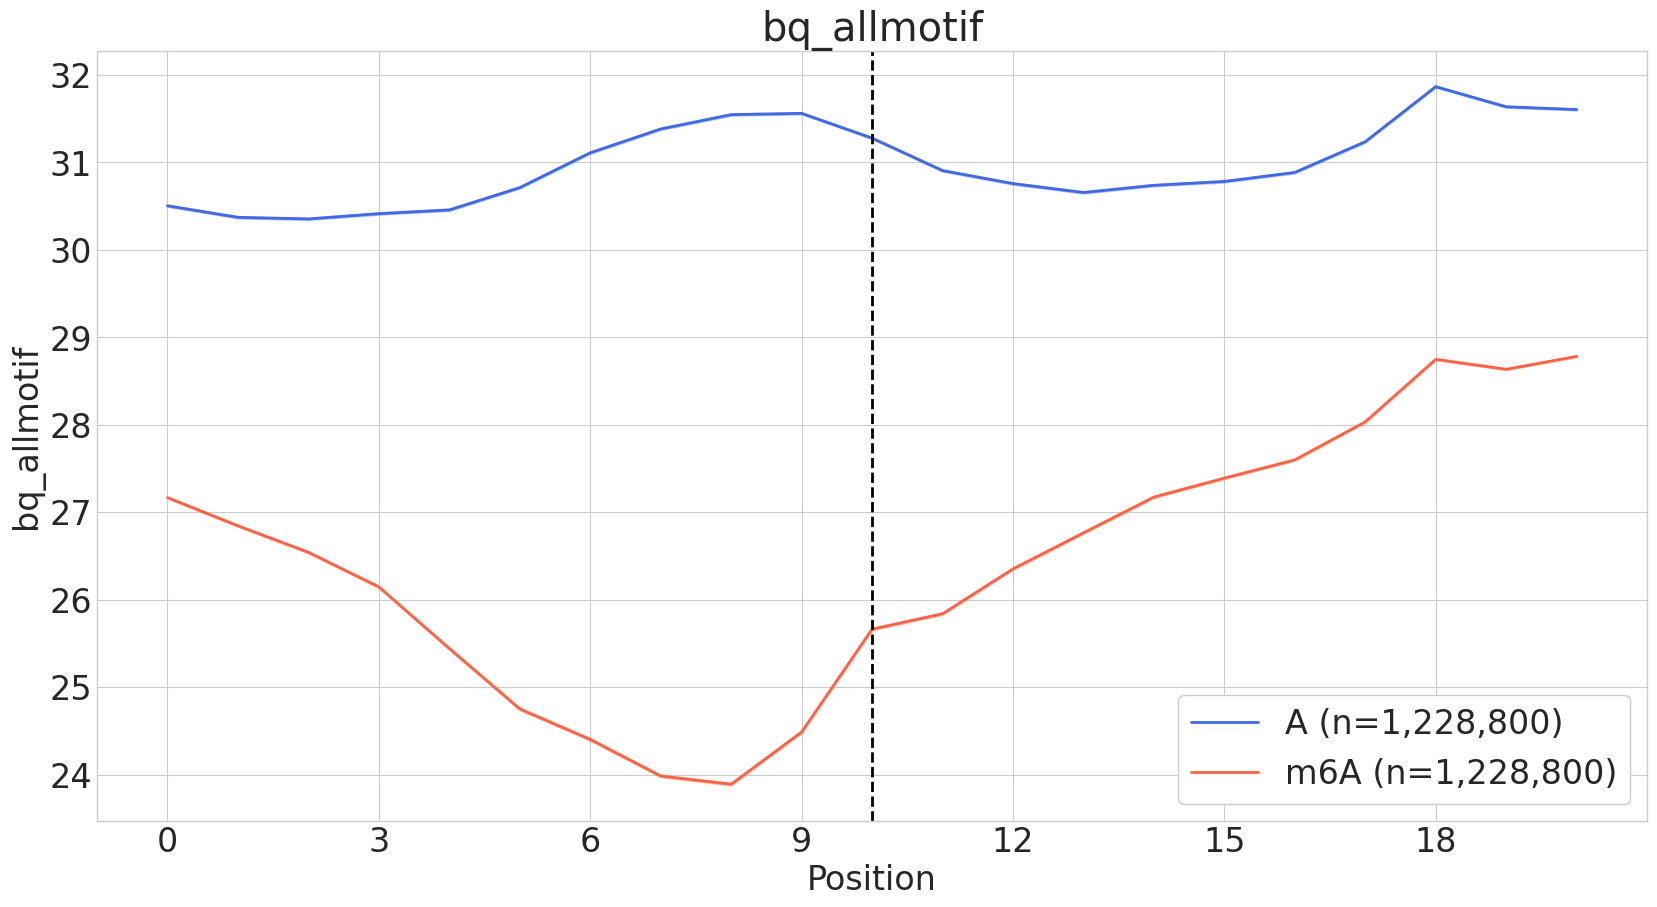

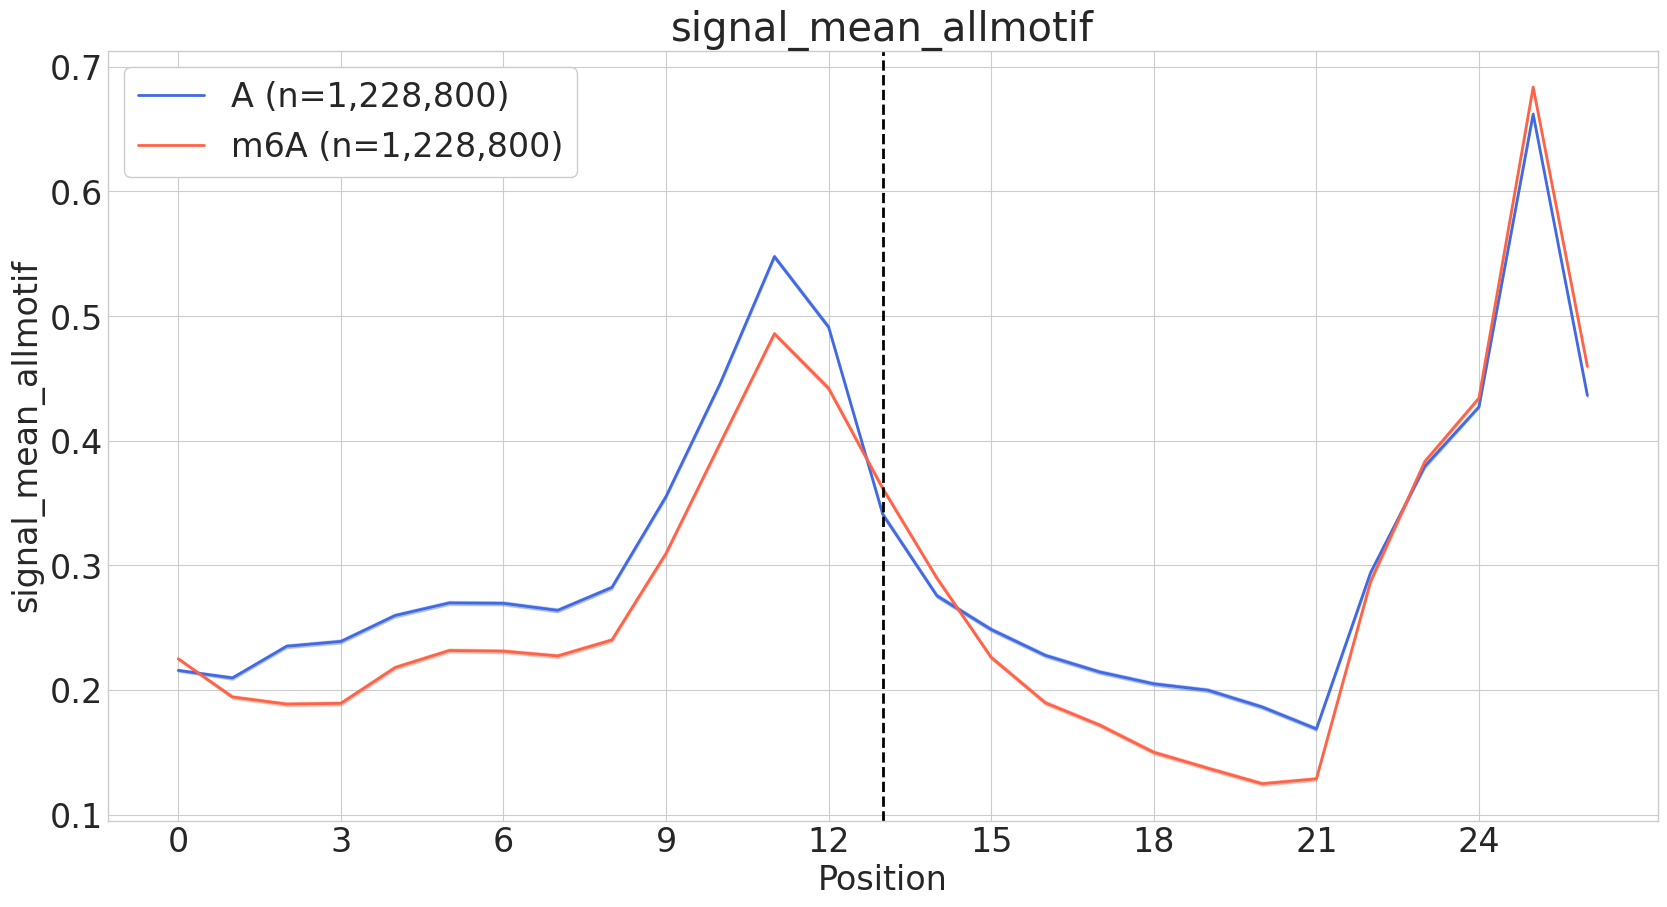

In [19]:
df_dict = {"A": a_df,
           "m6A": m6a_df}

for feature in ["bq", "signal_mean"]:
    feature_renamed = f"{feature}_allmotif"

    data_dict = {df_name: np.stack(df[feature].values) for df_name, df in df_dict.items()}

    mean_dict = {df_name: np.mean(data, axis=0) for df_name, data in data_dict.items()}
    ci95_dict = {df_name: 1.96*np.std(data, axis=0)/np.sqrt(data.shape[0]) for df_name, data in data_dict.items()}
    length_dict = {df_name: data.shape[0] for df_name, data in data_dict.items()}

    plot(mean_dict, ci95_dict, length_dict, feature_renamed, out_path)


In [20]:
print(a_df)
print(m6a_df)

                                                        bq  \
0        [38, 38, 37, 37, 38, 38, 39, 43, 44, 39, 40, 3...   
1        [25, 27, 28, 29, 39, 44, 42, 47, 38, 39, 37, 3...   
2        [31, 30, 32, 32, 33, 34, 38, 38, 43, 39, 38, 3...   
3        [24, 34, 31, 30, 29, 29, 30, 31, 31, 30, 27, 2...   
4        [29, 34, 33, 31, 31, 32, 33, 40, 40, 38, 33, 3...   
...                                                    ...   
1228795  [39, 34, 34, 33, 31, 30, 30, 31, 32, 34, 35, 3...   
1228796  [38, 38, 38, 37, 37, 37, 36, 33, 31, 16, 15, 1...   
1228797  [35, 35, 36, 37, 39, 42, 43, 41, 39, 36, 33, 3...   
1228798  [39, 38, 38, 39, 39, 39, 38, 38, 38, 38, 39, 3...   
1228799  [32, 32, 31, 31, 31, 31, 33, 35, 33, 32, 28, 2...   

                         motif  cb_idx  \
0        UCAGGCUGAAAAAAUUUAAUC       0   
1        UUUGAGAAAAAAACAUUAGGC       0   
2        CGACCGUCAAAAAUGCAAUGC       0   
3        GAGCGCAUAAAAAGGGGCGAC       0   
4        AAGCCAAGAAAAAGCGCUGUC       0   
...

In [31]:
df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0099/result/dorado-070/intermediates/segmented_tokenized/intermediates/move_df_split/17-21-279.pkl")

In [32]:
print(df)

                                                  mv  \
0  [6, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [6, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2  [6, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3  [6, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                read_id    ts       ns  sp  
0  c07ad39e-255c-434b-8860-f4d531c6548d  1400  1145708   0  
1  a1e1f55e-76ec-4687-a61a-993eae297f91  3050  2377920   0  
2  8e0e7432-65ff-4c58-a8d3-2fdb21392906  2650  2376421   0  
3  e6696f98-aa7a-4747-ae43-aeba9f93c884  4800  2195697   0  


In [23]:
df["len_bq"] = df["bq"].apply(len)
print(df)

          cb_idx  start_pos  end_pos  pos_RM  penalty     score  \
51175465       2        350      371     360        0  1.000000   
42736799       1        174      195     184        0  1.000000   
9920421        0        221      242     231        0  1.000000   
25310772       2        134      155     144        0  1.000000   
8833714        2        130      151     140        5  0.880952   
...          ...        ...      ...     ...      ...       ...   
33333375       2        356      377     366        0  1.000000   
60546804       2        465      486     475        7  0.833333   
38457406       2        240      261     250        0  1.000000   
39946203       0        307      328     317        3  0.928571   
1447778        1        103      124     113        5  0.880952   

                                       read_id  total_score  \
51175465  4e02ac59-6e05-49d8-b088-a97e98280bb0    17.166667   
42736799  cdf587db-0dc9-492b-a9bf-08e599d55aaf    14.928571   
992042

In [38]:
ext_df_0118 = "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0118/ON0118/result/intermediates/block_df.pkl.bqextended.sampled.pkl"
ext_df_0099 = "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0099/result/dorado-070/intermediates/block_df.pkl.bqextended.sampled.pkl"
ext_df_0092 = "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0092/ON0092/result/dorado-070/intermediates/block_df.pkl.bqextended.sampled.pkl"
ext_df_0096 = "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0096/result/dorado-070/intermediates/block_df.pkl.bqextended.sampled.pkl"

ext_df_0118 = pd.read_pickle(ext_df_0118)
ext_df_0099 = pd.read_pickle(ext_df_0099)
ext_df_0092 = pd.read_pickle(ext_df_0092)
ext_df_0096 = pd.read_pickle(ext_df_0096)


df_dict = {"ON0092": ext_df_0092, "ON0096": ext_df_0096, "ON0099": ext_df_0099, "ON0118": ext_df_0118}

In [39]:
print(ext_df_0092)

           cb_idx  start_pos  end_pos  pos_RM  penalty  score  \
42857275        0        211      232     221        0    1.0   
100707276       0        277      298     287        0    1.0   
118533024       0        245      266     255        0    1.0   
75265471        0         75       96      85        0    1.0   
39977105        0        292      313     302        0    1.0   
...           ...        ...      ...     ...      ...    ...   
35320864        2        151      172     161        0    1.0   
5335020         2         72       93      82        0    1.0   
75903076        2        214      235     224        0    1.0   
13018038        2        313      334     323        0    1.0   
3452186         2        396      417     406        0    1.0   

                                        read_id  total_score  \
42857275   1744d58a-ed8f-41cb-99d5-a3d3725a63fe    10.642857   
100707276  89d00b92-53bd-414a-9156-fbe4f7c2d265     8.142857   
118533024  d43b9190-3047-4c

In [40]:
a_bq_df = pd.concat([ext_df_0092, ext_df_0096]).copy().reset_index(drop=True)
m6a_bq_df = pd.concat([ext_df_0099, ext_df_0118]).copy().reset_index(drop=True)

In [41]:
a_bq_array = np.stack(a_bq_df["bq"].values)
m6a_bq_array = np.stack(m6a_bq_df["bq"].values)

print(a_bq_array.shape)
print(m6a_bq_array.shape)

(1160554, 27)
(1147292, 27)
